In [2]:
from pathlib import Path
from datetime import datetime
import os
import netCDF4 as nc  
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import xarray as xr

import sys
sys.path.append('/home/mba002/data/sitestore8/machine_learning/neuralhydrology')

import neuralhydrology.evaluation.metrics as nhm

In [3]:
def metric_generator(result_path, tmp_basins_path, spc_basins_path):

    tmp_basin_list = []
    spc_basin_list = []
    metric_list_cal=[]
    metric_list_tmp=[]
    metric_list_spc=[]
    metric_list_spc_tmp=[]
    missing_basins=[]

    with open(Path(tmp_basins_path)) as f:
        for line in f:
            # remove whitespace at the start and the newline at the end
            line = line.strip()
            tmp_basin_list.append(line)
    with open(Path(spc_basins_path)) as f:
        for line in f:
            # remove whitespace at the start and the newline at the end
            line = line.strip()
            spc_basin_list.append(line)

    # Temporal
    for basin in tqdm(tmp_basin_list):
        file_to_read=Path(result_path) / f'{basin}.csv'

        if not (os.path.isfile(file_to_read)):
            missing_basins.append(basin)
            continue

        df= pd.read_csv(file_to_read, index_col=[0])
        df_cal = df[df.index < '2018-01-01']
        df_tmp = df[(df.index >= '2018-01-01') & (df.index < '2024-12-31')]

        kge_cal=nhm.kge(df_cal['qobs_mmd'] , df_cal['qsim_mmd'])
        metric_list_cal.append((basin,kge_cal))

        kge_tmp=nhm.kge(df_tmp['qobs_mmd'] , df_tmp['qsim_mmd'])
        metric_list_tmp.append((basin,kge_tmp))

    metrics_cal=pd.DataFrame(metric_list_cal, columns=["basin","KGE"])  
    metrics_tmp=pd.DataFrame(metric_list_tmp, columns=["basin","KGE"]) 

    # Spatial
    for basin in tqdm(spc_basin_list):
        file_to_read=Path(result_path) / f'{basin}.csv'

        if not (os.path.isfile(file_to_read)):
            missing_basins.append(basin)
            continue

        df= pd.read_csv(file_to_read, index_col=[0])
        df_spc = df[df.index < '2011-01-01']
        df_spc_tmp = df[(df.index >= '2011-01-01') & (df.index < '2018-01-01')]

        kge_spc=nhm.kge(df_spc['qobs_mmd'] , df_spc['qsim_mmd'])
        metric_list_spc.append((basin,kge_spc))

        kge_spc_tmp=nhm.kge(df_spc_tmp['qobs_mmd'] , df_spc_tmp['qsim_mmd'])
        metric_list_spc_tmp.append((basin,kge_spc_tmp))

    metrics_spc=pd.DataFrame(metric_list_spc, columns=["basin","KGE"])  
    metrics_spc_tmp=pd.DataFrame(metric_list_spc_tmp, columns=["basin","KGE"]) 

    # metric.to_csv(run_dir+"/"+ 'metrics_tmprics.csv')
    metrics_cal.to_csv("results/"+'metrics' +'_cal' + '.csv')
    metrics_tmp.to_csv("results/"+'metrics' +'_tmp' + '.csv')
    # metrics_spc.to_csv("runs/"+'metrics' +'_spc' + '.csv')
    # metrics_spc_tmp.to_csv("runs/"+'metrics' +'_spc_tmp' + '.csv')
    return metrics_cal, metrics_tmp, metrics_spc, metrics_spc_tmp
    # return metrics_cal, metrics_tmp

In [4]:
# Define variables
result_path= '../apply_EG/results/'#'/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results_NSRPS_SGv2_geophy'
tmp_basins_path = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/data/LSTM_CaSR3.2_forcings_2000_2023/basins/basins_for_boxplots.txt'
spc_basins_path = '/home/mba002/LSTM_scripts/marie_scripts/new_bassin/missing_bassin.txt'
#'/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/data/LSTM_CaSR3.2_forcings_2000_2023/basins/no_basins.txt' 

metrics_cal, metrics_tmp, metrics_spc, metrics_spc_tmp = metric_generator(result_path, tmp_basins_path, spc_basins_path)

# making sure there are no nans
metrics_cal = metrics_cal.dropna()
metrics_tmp = metrics_tmp.dropna()
metrics_spc = metrics_spc.dropna()
metrics_spc_tmp = metrics_spc_tmp.dropna()
# metrics_cal, metrics_tmp = metric_generator(result_path, tmp_basins_path, spc_basins_path)

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/439 [00:00<?, ?it/s]

[205, 202, 203]


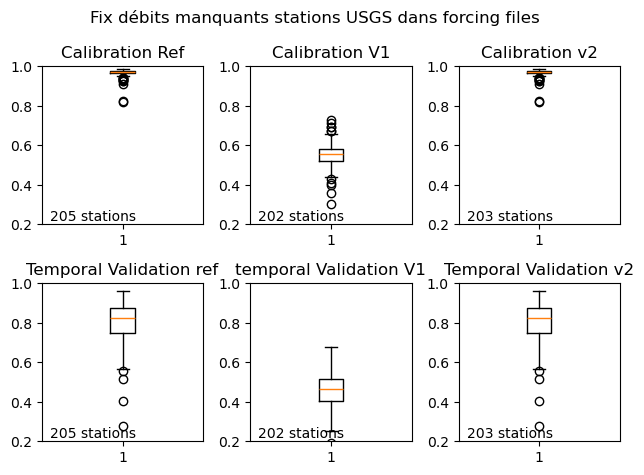

In [6]:
metrics_cal1 = pd.read_csv("/home/mba002/LSTM/new_bassin/experiment/apply_575_basins/metrics_cal_2.csv")
metrics_tmp1 = pd.read_csv("/home/mba002/LSTM/new_bassin/experiment/apply_575_basins/metrics_tmp_2.csv")

metrics_og = pd.read_csv("/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results_NSRPS_SGv2_geophy/metrics_tmp_2018-2023.csv")
metrics_og_cal = pd.read_csv("/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results_NSRPS_SGv2_geophy/metrics_cal_2001-2017.csv")

stn_nb = [len(metrics_og['KGE'].dropna()),len(metrics_cal1['KGE'].dropna()),len(metrics_cal['KGE'])]

print(stn_nb)
fig, axs = plt.subplots(2,3)
fig.suptitle("Fix débits manquants stations USGS dans forcing files")

axs[0, 0].boxplot(metrics_og_cal['KGE'].dropna())
axs[0, 0].set_title('Calibration Ref')

axs[0, 1].boxplot(metrics_cal1['KGE'].dropna())
axs[0, 1].set_title('Calibration V1')

axs[0,2].boxplot(metrics_cal['KGE'])
axs[0,2].set_title('Calibration v2')


axs[1,0].boxplot(metrics_og['KGE'].dropna())
axs[1,0].set_title('Temporal Validation ref')

axs[1, 1].boxplot(metrics_tmp1['KGE'].dropna())
axs[1, 1].set_title('temporal Validation V1')

axs[1,2].boxplot(metrics_tmp['KGE'])
axs[1,2].set_title('Temporal Validation v2')





for i in range (0,2):
    for j in range (0,3):
        axs[i,j].text(0.55,0.22, f"{stn_nb[j]} stations")
        axs[i,j].set_ylim(0.2,1)

# Multiple box plots on one Axes
plt.tight_layout()

plt.show()
#fig.savefig('runs/boxplot.png')

In [5]:
metric_original["KGE"]

NameError: name 'metric_original' is not defined

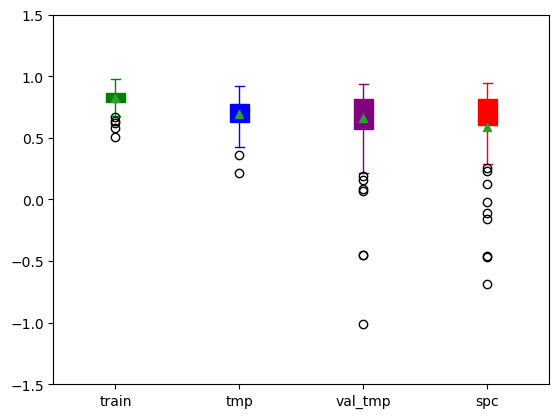

In [6]:
# data = [metrics_cal['KGE'], metrics_tmp['KGE'], metrics_spc['KGE'], metrics_spc_tmp['KGE']]
data = [metrics_cal['KGE'].dropna(), metrics_tmp['KGE'].dropna()]

# Multiple box plots on one Axes
# fig, ax = plt.subplots()
# ax.boxplot(data)

# plt.xticks(ticks=[1,2], labels=['calibration', 'validation'])
# # plt.ylim(-0.5,1)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.ylim(0.15, 1.05)
# plt.title(f'KGE (2009) for {len(metrics_cal)} stations', size='16')
# plt.show()
# fig.savefig('runs/boxplot_cal_val.png')


# import matplotlib.pyplot as plt

def color_boxplot(data, color, pos, ax=None):
    ax = ax or plt.gca()
    bp = ax.boxplot(data, patch_artist=True,  showmeans=True, positions=pos)
    for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(bp[item], color=color)


data1 = metrics_cal['KGE']
data2 = metrics_tmp['KGE']
data3 = metrics_spc['KGE']
data4 = metrics_spc_tmp['KGE']

fig, ax = plt.subplots()
bp1 = color_boxplot(data1, 'green', [1])
bp2 = color_boxplot(data2, 'blue', [2])
bp1 = color_boxplot(data3, 'purple', [3])
bp2 = color_boxplot(data4, 'red', [4])
ax.autoscale()
ax.set_ylim(-1.5,1.5)
ax.set(xticks=[1,2,3,4], xticklabels=['train','tmp', 'val_tmp', 'spc'])
plt.show()

In [7]:
def metric_analysis(df_metric):
    
    d=df_metric['KGE']
    whis=1.5
    
    # finding the 1st quartile
    q1 = np.quantile(d, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(d, 0.75)
    med = np.median(d)

    # finding the iqr region
    iqr = q3-q1

    # # finding upper and lower whiskers
    # upper_bound = q3+(1.5*iqr)
    # lower_bound = q1-(1.5*iqr)
    

    # get high extreme
    iq = q3 - q1
    hi_val = q3 + whis * iq
    wisk_hi = np.compress(d <= hi_val, d)
    if len(wisk_hi) == 0 or np.max(wisk_hi) < q3:
        wisk_hi = q3
    else:
        wisk_hi = max(wisk_hi)

    # get low extreme
    lo_val = q1 - whis * iq
    wisk_lo = np.compress(d >= lo_val, d)
    if len(wisk_lo) == 0 or np.min(wisk_lo) > q1:
        wisk_lo = q1
    else:
        wisk_lo = min(wisk_lo)

    # Calculate standard deviation
    std_dev = np.std(d)
        
    ##get the outliers
    outliers=df_metric[df_metric['KGE']< wisk_lo][['basin' ,'KGE']]
    
    print('Median: ',med)
    print('Std: ', std_dev)
    # print('upper_bound: ', upper_bound)
    # print('lower_bound: ', lower_bound)
    print('wisk_hi: ',wisk_hi)
    print('wisk_low: ',wisk_lo)

    print('*' *50)
    print("outliers: ")
    return outliers

# Calibration

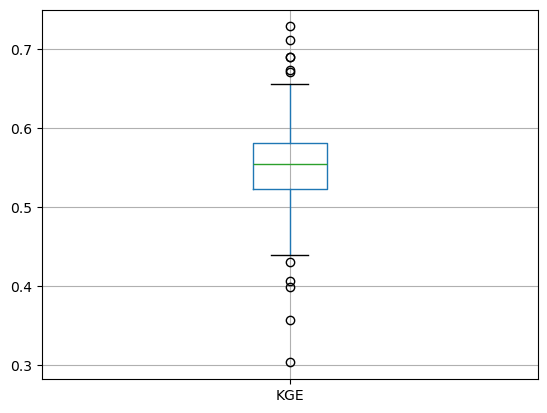

NameError: name 'metric_analysis' is not defined

In [9]:
metrics_cal.boxplot('KGE')
plt.show()

Train_outliers=metric_analysis(metrics_cal)
Train_outliers

# Temporal Validation

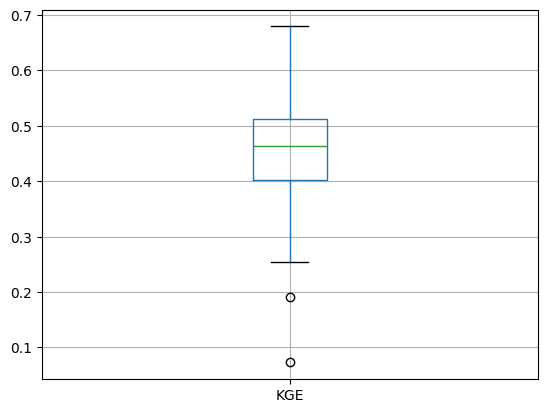

NameError: name 'metric_analysis' is not defined

In [7]:
metrics_tmp.boxplot('KGE')
plt.show()
Tmp_outliers=metric_analysis(metrics_tmp)
Tmp_outliers

# Spatial Validation

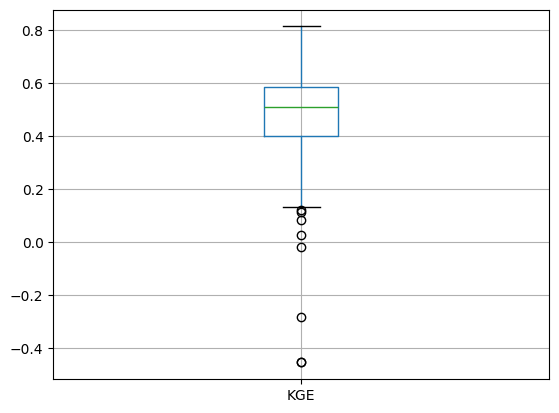

NameError: name 'metric_analysis' is not defined

In [8]:
metrics_spc.boxplot('KGE')
plt.show()
valtmp_outliers=metric_analysis(metrics_spc)
valtmp_outliers

# Spatio-Temporal Validation

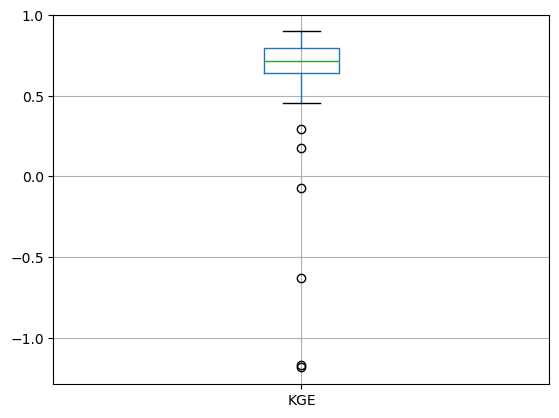

Median:  0.7143262823331911
Std:  0.38003904418358475
wisk_hi:  0.8984446968981782
wisk_low:  0.45681602975040714
**************************************************
outliers: 


,basin,KGE
2,02AD012,-0.072862
8,02BE002,-0.631206
34,02HF002,0.178531
42,02KF005,-1.168260
49,02LE025,-1.183688
50,02LG005,0.292874


In [11]:
metrics_spc_tmp.boxplot('KGE')
plt.show()
spc_outliers=metric_analysis(metrics_spc_tmp)
spc_outliers

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# update list of results files to consider for boxplots
experiments_paths = {}
experiments_paths['212_basins'] = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results_NSRPS_SGv2_geophy/metrics_tmp_2018-2023.csv'
# experiments_paths['RDPS-RDPA'] = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2000_2018/results_clim_indices_2001-2023/metrics_tmp_21-23.csv'
experiments_paths['all_basins'] = '/home/mba002/LSTM/new_bassin/experiment/apply_575_basins/results/metrics_tmp.csv'
# experiments_paths['train_2001-17'] = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results/metrics_tmp_21-23.csv'


old_exp = pd.read_csv( experiments_paths['212_basins'])
new_exp = pd.read_csv( experiments_paths['all_basins'])

if len(old_exp['KGE'].dropna()) != len(new_exp['KGE'].dropna()):
    print("diff lengths")
data = pd.merge(old_exp, new_exp, on='basin', how='inner',)

#output_folder = Path(output_folder)
#output_folder.mkdir(parents=False, exist_ok=True)

data = [old_exp['KGE'].dropna(),new_exp['KGE'].dropna()]
names = []
# nb_stats_old = 0
# first = True
# for name in experiments_paths:
#     names.append(name)
#     print(experiments_paths[name])
#     exp_vec = pd.read_csv(experiments_paths[name])['KGE']
#     data.append(exp_vec.dropna())
nb_stats = len(new_exp.dropna())
#     print(nb_stats)
#     if (first):
#         first = False
#         nb_stats_old = nb_stats
#     else:
#         if (nb_stats != nb_stats_old):
#             print('nb_stats_old=',nb_stats_old)
#             print('nb_stats=',nb_stats)

#             #print('error: not the same number of stations considered in the different experiments, aborting')
#             #return

nb_exps = len(names)
temp_period= " 2018-2024"
#if not (os.path.isdir(output_folder)):
#    os.mkdir(output_folder)

fig, ax = plt.subplots()
ax.boxplot(data)
plt.xticks(ticks=list(range(1,nb_exps+1)), labels=names)
# plt.ylim(-0.5,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.ylim(0.15, 1.05)
plt.title('KGE(09), '+ str(int(nb_stats)) + ' stations, over ' + temp_period, size='16')
plt.show()
#fig.savefig(str(output_folder)+'/bplots_over_'+temp_period+'.png')

#return
plt.show()
#compare_LSTM_exps_bplots('2001-2017','/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/Comp_geophy')

diff lengths


MergeError: Can only pass argument "on" OR "left_index" and "right_index", not a combination of both.

In [15]:
data

,Unnamed: 0_x,basin,KGE_x,Unnamed: 0_y,KGE_y
0,0,02AB017,0.618007,0,0.347210
1,1,02AC001,0.777455,1,0.598368
2,2,02AC002,0.827543,2,0.478030
3,3,02AD010,0.721864,3,0.328412
4,4,02BA003,0.863604,4,0.449066
...,...,...,...,...,...
198,200,04209000,0.666794,198,0.361833
199,201,04214500,0.851678,199,0.473667
200,202,04220045,0.851663,200,NaN
201,203,04249000,0.886851,201,0.612503


In [77]:
import matplotlib.dates as mdates

stn_list = pd.read_csv("/home/mba002/LSTM/new_bassin/experiment/575_basins/basins/bassin_644.txt", header = None)
stn_list.columns = ['Station_name']
stn_list=stn_list["Station_name"].squeeze().tolist()

data_path_EG = '/home/ega001/store8/machine_learning/cal_val_CaSR3.2_EG/experiments/train_212_2001_2017/results_NSRPS_SGv2_geophy/'
data_path_MB = '/home/mba002/LSTM/new_bassin/experiment/apply_575_basins/results/'
for i in range (0,len(stn_list)):

    path_EG = os.path.join(data_path_EG , stn_list[i]+".csv")
    path_MB = os.path.join(data_path_MB , stn_list[i]+".csv")

    if os.path.exists(path_EG) == False or os.path.exists(path_MB)==False:
        continue 

    data_EG = pd.read_csv(path_EG, index_col = 0)
    data_MB = pd.read_csv(path_MB, index_col= 0)
    
    plt.figure(i)
    fig, axs = plt.subplots(2,1,)
    axs[0].plot(data_EG["qsim_m3s"][4000:6000], label = "qsim_m3s_EG")
    axs[0].plot(data_MB["qsim_m3s"][4000:6000], label = "qsim_m3s_MB", linestyle = ':')
    axs[0].legend()
    axs[1].plot(data_EG["qsim_m3s"][4000:6000]-data_MB["qsim_m3s"][4000:6000], label = "qsim_m3s_EG")

    for jj in range (0,2):

        # Set the xtick intervals (e.g., monthly)
        axs[jj].xaxis.set_major_locator(mdates.MonthLocator(interval=12))

        # Rotate labels to prevent overlap
        plt.gcf().autofmt_xdate() 

    axs[0].set_title(f"Hydrogramme station : {stn_list[i]}")

    plt.savefig(f'/home/mba002/LSTM/new_bassin/experiment/apply_575_basins/figures/{stn_list[i]}')
    plt.close()

/tmp/mba002/3220623/ipykernel_3223160/3244870301.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2,1,)
/tmp/mba002/3220623/ipykernel_3223160/3244870301.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(i)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>